Lecture 3.ipynb file

# PyMC Distributions + 2 Practice Models

**Goal:** define every distribution from the PPT as **x1, x2, ..., x13** in **one** PyMC model, then plot any one by changing just:```python
varname = "x7"
```

Then at the end:
- **Model 1:** Bernoulli (coin flips)
- **Model 2:** your learning activity

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

## 1) All distributions we need so far in this course

**Discrete (PPT):** Bernoulli, Binomial, Categorical, Multinomial, Poisson, Zero-Inflated Poisson  
**Continuous (PPT):** Beta, Normal, HalfNormal, Cauchy, HalfCauchy, Uniform, StudentT


Below we pick simple example parameters so they run anywhere.

In [39]:
with pm.Model() as all_dists:
    # -------- Discrete --------
    x1  = pm.Bernoulli("x1", p=0.30)                 # Bernoulli
    x2  = pm.Binomial("x2", n=10, p=0.40)            # Binomial
    x3  = pm.Categorical("x3", p=np.array([0.2, 0.5, 0.3]))  # Categorical (0,1,2)
    x4  = pm.Multinomial("x4", n=12, p=np.array([0.2, 0.5, 0.3]))  # Multinomial (vector)
    x5  = pm.Poisson("x5", mu=4.0)                   # Poisson
    x6  = pm.ZeroInflatedPoisson("x6", psi=0.25, mu=4.0)     # ZIP

    # -------- Continuous --------
    x7  = pm.Beta("x7", alpha=1, beta=1)             # Beta in (0,1)
    x8  = pm.Normal("x8", mu=10, sigma=20)            # Normal
    x9  = pm.HalfNormal("x9", sigma=2)               # HalfNormal > 0
    x10 = pm.Cauchy("x10", alpha=0, beta=1)          # Cauchy
    x11 = pm.HalfCauchy("x11", beta=1)               # HalfCauchy > 0
    x12 = pm.Uniform("x12", lower=10, upper=20)       # Uniform
    x13 = pm.StudentT("x13", nu=5, mu=0, sigma=1)    # StudentT
    
         
    

In [ ]:
all_dists

# runn this cell to see statistical notations of above variables

In [41]:
# Draw prior predictive samples ONCE (covers all x1..x13)
idata = pm.sample_prior_predictive(samples=5000, model=all_dists)

labels = {
    "x1":  "Bernoulli(p=0.30)",
    "x2":  "Binomial(n=10, p=0.40)",
    "x3":  "Categorical(p=[0.2,0.5,0.3])",
    "x4":  "Multinomial(n=12, p=[0.2,0.5,0.3])",
    "x5":  "Poisson(mu=4)",
    "x6":  "ZeroInflatedPoisson(psi=0.25, mu=4)",
    "x7":  "Beta(alpha=2, beta=5)",
    "x8":  "Normal(mu=10, sigma=20)",
    "x9":  "HalfNormal(sigma=2)",
    "x10": "Cauchy(alpha=0, beta=1)",
    "x11": "HalfCauchy(beta=1)",
    "x12": "Uniform(-1, 1)",
    "x13": "StudentT(nu=5, mu=0, sigma=1)",
}

Sampling: [x1, x10, x11, x12, x13, x2, x3, x4, x5, x6, x7, x8, x9]


## 2) One block to plot (change only `varname = "xN"`)

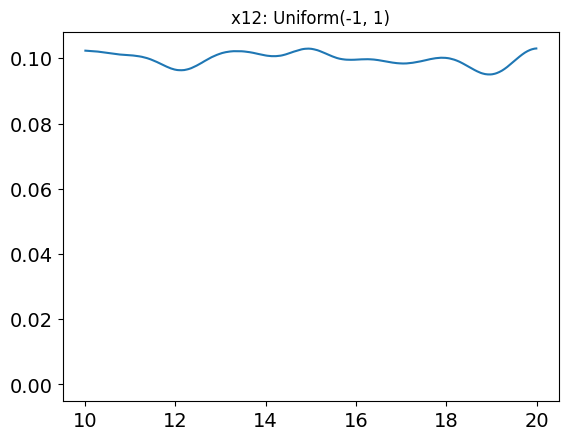

In [42]:
varname = "x12"  # <--- CHANGE ONLY THIS: "x1" .. "x13"

vals = idata.prior[varname].values
vals_1d = np.asarray(vals).ravel()   # works even if the variable is a vector (e.g., Multinomial)

az.plot_dist(vals_1d)
plt.title(f"{varname}: {labels.get(varname, varname)}")
plt.show()

-----

---------------------

## 3) Practice Models (from last slide idea)

### Model 1 (Discrete): coin flips
- Heads=1, Tails=0
- prior: `p ~ Beta(1,5)`
- likelihood: `y ~ Bernoulli(p)`

### data

In [17]:
s = "HHTTHHHTTH"          # change this string for practice or you can [0,0,0,0,0] directly as we already disscussed in meeting
y = np.array([1 if c=="H" else 0 for c in s])


In [46]:
with pm.Model() as model1:
    #prior
    pr = pm.Beta("pr", alpha=1, beta=5)
    #liklihood
    pm.Bernoulli('y',p=pr,observed=y)
    idata1 = pm.sample(100,chains=1)
    

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [pr]


C:\Users\Almas\anaconda3\envs\python3\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 1_000 tune and 100 draw iterations (1_000 + 100 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [47]:
pm.summary(idata1)

arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pr,0.402,0.124,0.171,0.63,0.023,0.009,29.0,60.0,NaN


array([[<Axes: title={'center': 'pr'}>, <Axes: title={'center': 'pr'}>]],
      dtype=object)

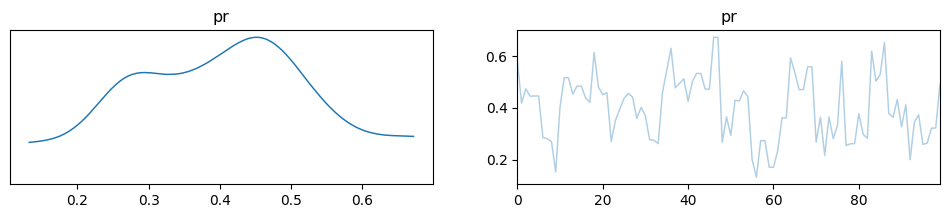

In [ ]:
pm.plot_trace(idata1)






---------


### Model 2 
- prior: `p ~ Uniform`

- likelihood: `y ~ Bernoulli(p)`

In [ ]:
# write your model here and test its estimation like above





# students challenge : try to model the data below with an appropriate likelihood and prior




Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [p]


C:\Users\Almas\anaconda3\envs\python3\Lib\site-packages\rich\live.py:231: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 15 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.584,0.133,0.334,0.822,0.005,0.003,696.0,829.0,1.0
